In [1]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
import numpy as np

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# Load train and test sets
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform)

# Convert to NumPy arrays
def convert_to_numpy(dataset):
    data = []
    labels = []
    for img, label in dataset:
        data.append(np.array(img.squeeze()))  # shape: (28, 28)
        labels.append(label)
    return np.array(data), np.array(labels)

x_train, y_train = convert_to_numpy(train_dataset)
x_test, y_test = convert_to_numpy(test_dataset)

100%|██████████| 170M/170M [00:17<00:00, 9.70MB/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [3]:
np.random.seed(41)

from neural_network import NeuralNetwork

# Normalize and flatten
x_train_flat = x_train.reshape(x_train.shape[0], -1)
y_train_array = y_train

x_test_flat = x_test.reshape(x_test.shape[0], -1)
y_test_array = y_test

# Initialize the same network (you can increase hidden size if needed)
nn = NeuralNetwork(input_size=32*32, hidden_size=128)
learning_rate = 0.1
num_epochs = 20
batch_size = 64

losses = []
accuracies = []

for epoch in range(num_epochs):
    indices = np.arange(x_train_flat.shape[0])
    np.random.shuffle(indices)
    x_shuffled = x_train_flat[indices]
    y_shuffled = y_train_array[indices]
    
    epoch_loss = 0
    
    for i in range(0, x_train_flat.shape[0], batch_size):
        x_batch = x_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        predictions = nn.forward(x_batch)
        loss = nn.loss_function.forward(predictions, y_batch)
        epoch_loss += loss
        
        loss_grad = nn.loss_function.backward()
        nn.backward(loss_grad, learning_rate)
    
    full_preds = nn.forward(x_train_flat)
    predicted_classes = np.argmax(full_preds, axis=1)
    accuracy = np.mean(predicted_classes == y_train_array)
    
    avg_loss = epoch_loss / (x_train_flat.shape[0] / batch_size)
    losses.append(avg_loss)
    accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy * 100:.2f}%")

Epoch 1/20, Avg Loss: 2.3041, Accuracy: 11.23%
Epoch 2/20, Avg Loss: 2.2037, Accuracy: 25.86%
Epoch 3/20, Avg Loss: 2.0767, Accuracy: 22.72%
Epoch 4/20, Avg Loss: 1.9846, Accuracy: 25.79%
Epoch 5/20, Avg Loss: 1.8746, Accuracy: 26.97%
Epoch 6/20, Avg Loss: 1.8270, Accuracy: 29.04%
Epoch 7/20, Avg Loss: 1.7968, Accuracy: 33.67%
Epoch 8/20, Avg Loss: 1.7690, Accuracy: 27.85%
Epoch 9/20, Avg Loss: 1.7450, Accuracy: 34.66%
Epoch 10/20, Avg Loss: 1.7246, Accuracy: 34.38%
Epoch 11/20, Avg Loss: 1.7085, Accuracy: 38.10%
Epoch 12/20, Avg Loss: 1.6899, Accuracy: 38.27%
Epoch 13/20, Avg Loss: 1.6793, Accuracy: 33.92%
Epoch 14/20, Avg Loss: 1.6645, Accuracy: 39.97%
Epoch 15/20, Avg Loss: 1.6485, Accuracy: 39.32%
Epoch 16/20, Avg Loss: 1.6421, Accuracy: 34.40%
Epoch 17/20, Avg Loss: 1.6284, Accuracy: 36.36%
Epoch 18/20, Avg Loss: 1.6180, Accuracy: 37.15%
Epoch 19/20, Avg Loss: 1.6112, Accuracy: 40.00%
Epoch 20/20, Avg Loss: 1.5999, Accuracy: 41.33%


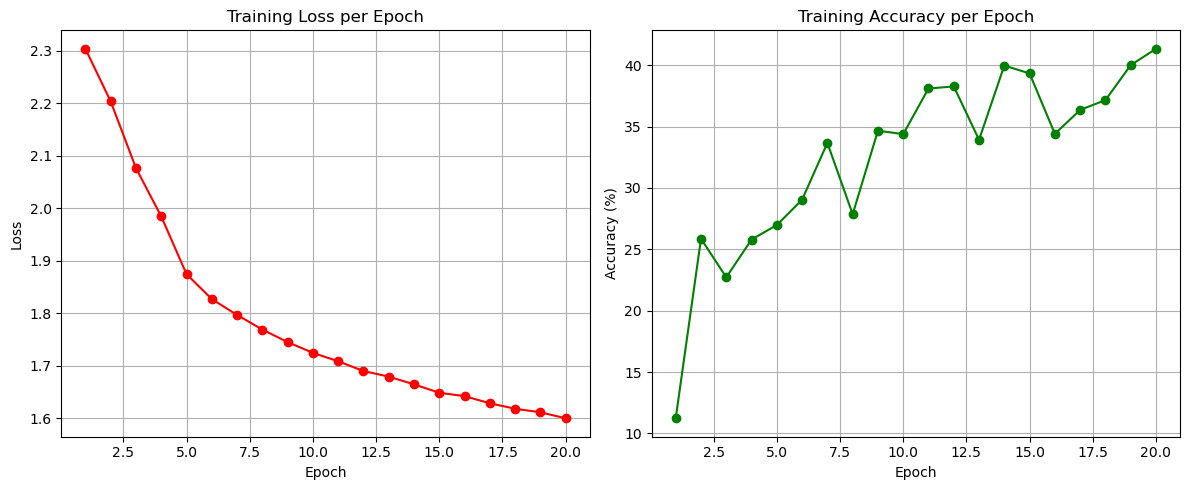

In [4]:
import matplotlib.pyplot as plt

# Plot loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, marker='o', color='red')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [a * 100 for a in accuracies], marker='o', color='green')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
x_test_flat = x_test.reshape(x_test.shape[0], -1)
y_test_array = np.array(y_test)

# Predict on test set
test_preds = nn.forward(x_test_flat)
predicted_labels = np.argmax(test_preds, axis=1)

# Calculate accuracy
test_accuracy = np.mean(predicted_labels == y_test_array)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")

✅ Test Accuracy: 37.20%
